In [1]:
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import os
import arviz as az

## Bayesian Linear Regression

- Download the data [here](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression/data). Here is a description of the features
    - ```Hours Studied```: The total number of hours spent studying by each student.
    - ```Previous Scores```: The scores obtained by students in previous tests.
    - ```Extracurricular Activities```: Whether the student participates in extracurricular activities (Yes or No).
    - ```Sleep Hours```: The average number of hours of sleep the student had per day.
    - ```Sample Question Papers Practiced```: The number of sample question papers the student practiced.
    - ```Performance Index```: A measure of the overall performance of each student. The performance index represents the student's academic performance

Suppose I was interested in modeling each student's performance index using the numerical features such as hours studied, previous scores, etc. I want to model it using a Bayesian framework. Lets say I know nothing about any of the numeric features, and make educated guesses on what ranges of values they can take

In [2]:
data_dir =  r"C:\Users\jluo1\Documents\repos\bayesian_statistics\data"
student_data = pd.read_csv(os.path.join(data_dir, "Student_Performance.csv"))
student_data.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [3]:
X = student_data.iloc[:, ~student_data.columns.isin(["Extracurricular Activities", "Performance Index"])]
Y = student_data["Performance Index"]

Here our model is:


$$ \beta_0 \sim \mathcal{N}(70, 20) $$
$$ \beta_1 \sim \mathcal{N}(4, 20) $$
$$ \beta_2 \sim \mathcal{N}(0, 20) $$
$$ \beta_3 \sim \mathcal{N}(6, 20) $$
$$ \beta_4 \sim \mathcal{N}(70, 20) $$
$$ \sigma \sim  \exp(1) $$

Letting $ \beta = [\beta_0 ... \beta_4] $ we have

$$ p(\beta | \mathcal{Y}, \mathcal{X}) \propto p(\mathcal{Y} | \mathcal{X}, \beta, \sigma)p(\beta) $$

where $\mathcal{X}$ is our feature (design) matrix and $\mathcal{Y}$ is our prediction

In [4]:
n_samples = 500
with pm.Model() as performanceIndexModel:

    intercept = pm.Normal("intercept", mu = 70, sigma = 20)
    beta_1 = pm.Normal("hours_studied", mu = 4, sigma = 20)
    beta_2 = pm.Normal("prev_scores", mu = 0, sigma =20 )
    beta_3 = pm.Normal("sleep_hrs", mu = 6, sigma = 20)
    beta_4 = pm.Normal("prac_papers", mu = 0, sigma = 20)
    sigma = pm.Exponential("sigma", lam = 1)

    beta = pm.math.stack([beta_1, beta_2, beta_3, beta_4])
    eta = pm.Deterministic("eta", intercept + pm.math.dot(X, beta))

    observed = pm.Normal("observed", mu = eta, sigma = sigma, observed= Y)

    # Prior distributions
    prior_idata = pm.sample_prior_predictive()

    # Posterior Distribution
    posterior_idata = pm.sample(n_samples, njobs = 2)

Sampling: [hours_studied, intercept, observed, prac_papers, prev_scores, sigma, sleep_hrs]
NUTS[nutpie]: [intercept, hours_studied, prev_scores, sleep_hrs, prac_papers, sigma]


Output()

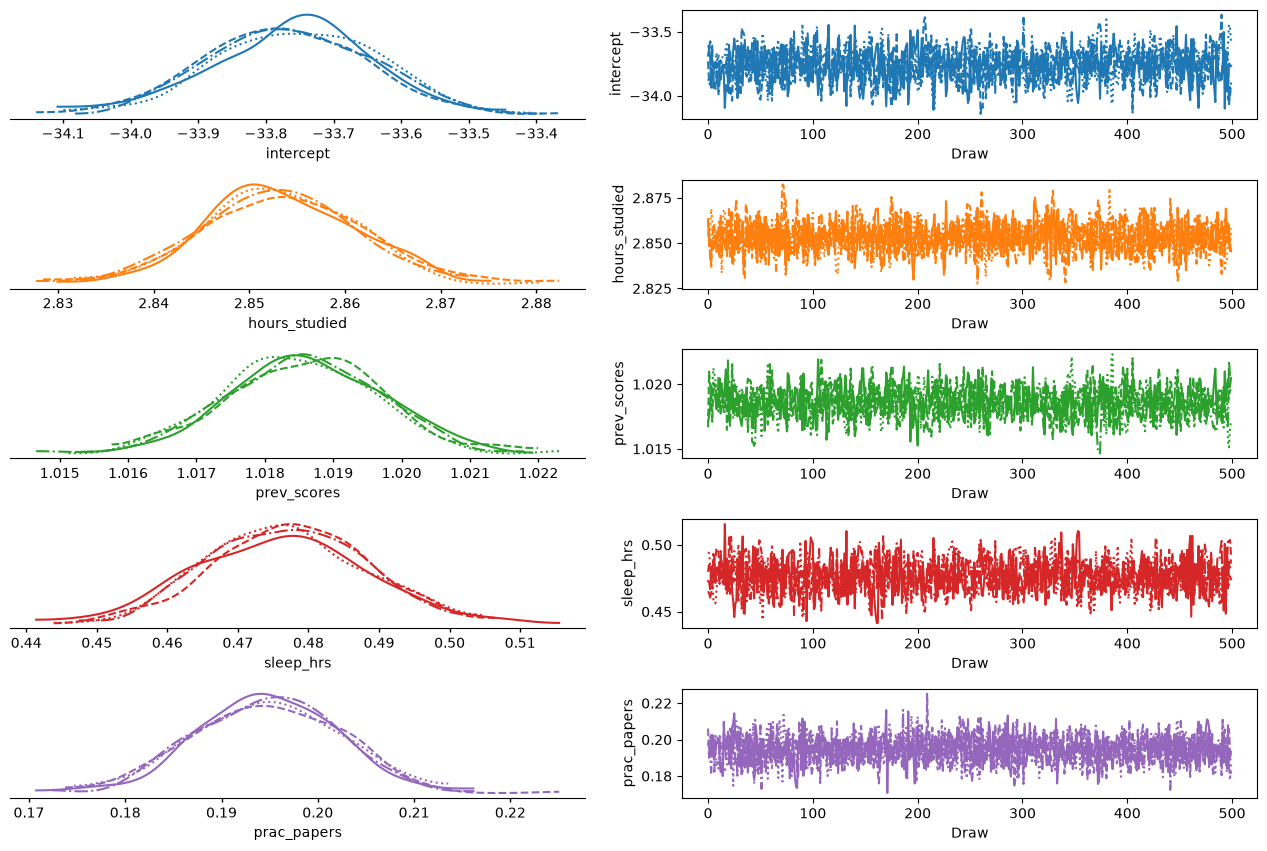

In [5]:
az.plot_trace_dist(posterior_idata, var_names = ["intercept",  "hours_studied", "prev_scores", "sleep_hrs", "prac_papers"])
plt.tight_layout()